# Step 9 Test 段一次性评估

---
## 1  Load all upstream artifacts

In [186]:
import json
import numpy as np
import pandas as pd
import joblib
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

DATA = Path('data')

with open(DATA / 'splits.json') as f:
    splits = json.load(f)
train_start=pd.Timestamp(splits['train']['start'])
train_end=pd.Timestamp(splits['train']['end'])
test_start = pd.Timestamp(splits['test']['start'])
test_end   = pd.Timestamp(splits['test']['end'])
val_start  = pd.Timestamp(splits['val']['start'])
val_end    = pd.Timestamp(splits['val']['end'])

with open(DATA / 'signal_bins.json') as f:
    signal_bins = json.load(f)

with open(DATA / 'execution_params.json') as f:
    execution_params = json.load(f)
final_params = execution_params['final_params']

lookup_table   = pd.read_parquet(DATA / 'lookup_table.parquet')
regime_forward = pd.read_parquet(DATA / 'regime_forward.parquet')
regime_post    = pd.read_parquet(DATA / 'regime_posterior.parquet')
X_P_residual   = pd.read_parquet(DATA / 'X_P_residual.parquet')
regime_all     = regime_forward["regime"]
ohlcv          = pd.read_parquet(DATA / 'spy_minute_clean.parquet')
val_backtest=pd.read_parquet(DATA / 'val_backtest.parquet')

# ── 加载 regime-conditional 模型 ──────────────────────────
with open(DATA / 'P_model.pkl', 'rb') as f:
    P_bundle = pickle.load(f)

regime_models = P_bundle["regime_models"]
scaler_resid  = P_bundle["scaler_resid"]
feature_names = P_bundle["feature_names"]
alpha_locked  = P_bundle["alpha_locked"]
REGIME_LABELS = P_bundle["regime_labels"]
K_FINAL       = P_bundle["K_FINAL"]
feature_set   = P_bundle["feature_set"]

print('test window  :', test_start.date(), '->', test_end.date())
print('final_params :')
for k, v in final_params.items():
    print(f'  {k:35s}: {v}')
print()
print('K_FINAL      :', K_FINAL)
print('feature_names:', feature_names)
print('feature_set  :', feature_set)


test window  : 2024-08-28 -> 2025-12-31
final_params :
  low_conf_size                      : 0.5
  regime_uncertainty_threshold       : 0.6
  cost_per_turnover_bp               : 2.0
  min_samples_per_cell               : 30
  r0_bins                            : 5
  r1_bins                            : 5

K_FINAL      : 2
feature_names: ['CloseLoc_resid', 'SignedVolume_z252_resid', 'PriceVolCorr_z252_resid', 'Overnight_resid', 'Mom_60d_resid', 'Mom_20d_resid']
feature_set  : residual_only_4dim


In [187]:
# ── 补充 test 时间窗口（加载 cell 里只定义了 val） ────────
test_start = pd.Timestamp(splits['test']['start'])
test_end   = pd.Timestamp(splits['test']['end'])

# ── 列名映射 ──────────────────────────────────────────────
col_map = {}
for fn in feature_names:
    base = fn.replace('_resid', '')
    if fn in X_P_residual.columns:
        col_map[fn] = fn
    elif base in X_P_residual.columns:
        col_map[fn] = base
    else:
        raise KeyError(f'cannot locate {fn} (or {base}) in X_P_residual')

# ── 构造目标变量 r_next ───────────────────────────────────
daily_close = ohlcv.groupby(ohlcv.index.normalize())['close'].last()
daily_close.index = pd.to_datetime(daily_close.index).tz_localize(None)
log_ret = np.log(daily_close / daily_close.shift(1))
r_next  = log_ret.shift(-1).rename('r_next')

# ── 切出 test 段并去掉边界 ────────────────────────────────
test_dates         = X_P_residual.loc[test_start:test_end].index
resid_test         = X_P_residual.loc[test_dates]
resid_test_trimmed = resid_test.iloc[5:]

# ── 按 regime 分组预测 ────────────────────────────────────
ordered_cols = [col_map[fn] for fn in feature_names]
X_raw    = resid_test_trimmed[ordered_cols].values
X_scaled = scaler_resid.transform(X_raw)

seg_regime = regime_all.reindex(resid_test_trimmed.index)

pred = np.full(len(resid_test_trimmed), np.nan)
for r in range(K_FINAL):
    mask = (seg_regime.values == r)
    if mask.sum() == 0:
        continue
    pred[mask] = regime_models[r].predict(X_scaled[mask])

signal = pd.Series(pred, index=resid_test_trimmed.index, name='signal')

# ── 组装 test_frame ───────────────────────────────────────
reg_col  = regime_forward.columns[0]
post_arr = regime_post.loc[resid_test_trimmed.index].values
post_max = pd.Series(
    post_arr.max(axis=1),
    index=resid_test_trimmed.index,
    name='posterior_max'
)

test_frame = pd.concat([
    regime_forward.loc[resid_test_trimmed.index, reg_col].rename('regime'),
    post_max,
    signal,
    r_next.loc[resid_test_trimmed.index].rename('r_next'),
], axis=1)

print('test_frame shape :', test_frame.shape)
print('boundary trim    : dropped first 5 rows (L1 segment edge)')
print('first date       :', test_frame.index[0].date())
print('last date        :', test_frame.index[-1].date())
print()
print('NaN per column:')
print(test_frame.isna().sum())
print()
print('regime distribution in test:')
print(test_frame['regime'].value_counts().sort_index())
print()
print(test_frame.head(6))
print(test_frame.tail(6))

test_frame shape : (332, 4)
boundary trim    : dropped first 5 rows (L1 segment edge)
first date       : 2024-09-05
last date        : 2025-12-31

NaN per column:
regime           0
posterior_max    0
signal           0
r_next           1
dtype: int64

regime distribution in test:
regime
0    120
1    212
Name: count, dtype: int64

            regime  posterior_max    signal    r_next
date                                                 
2024-09-05       1       0.598016  0.000555 -0.016716
2024-09-06       0       1.000000  0.001432  0.011023
2024-09-09       0       1.000000  0.001826  0.004383
2024-09-10       1       0.976970  0.000700  0.010044
2024-09-11       0       0.999867 -0.001511  0.008371
2024-09-12       0       0.999121 -0.001615  0.005210
            regime  posterior_max    signal    r_next
date                                                 
2025-12-23       1       0.999893  0.000937  0.002867
2025-12-24       0       1.000000 -0.000435  0.000529
2025-12-26       1

---
### 2.2 Bin assignment and lookup_table merge

In [188]:
edges_by_regime = {}
for k, v in signal_bins['bin_edges'].items():
    edges_by_regime[int(k)] = np.array(
        [-np.inf if e == '-inf' else (np.inf if e == 'inf' else float(e)) for e in v]
    )

def assign_bin(signal_value, regime, edges_dict):
    edges = edges_dict[int(regime)]
    edges_inner = edges[1:-1]
    return int(np.digitize([signal_value], edges_inner)[0])

test_frame['signal_bin'] = test_frame.apply(
    lambda r: assign_bin(r['signal'], r['regime'], edges_by_regime), axis=1
)

lk = lookup_table.reset_index() if lookup_table.index.name is not None else lookup_table.copy()

test_frame = test_frame.merge(
    lk[['regime', 'signal_bin', 'mean_ret', 'confidence']],
    on=['regime', 'signal_bin'],
    how='left',
)
test_frame.index = resid_test_trimmed.index

print('test_frame shape after merge   :', test_frame.shape)
print('rows missing cell merge        :', test_frame['confidence'].isna().sum())
print()
print('=== test (regime, signal_bin) cell counts ===')
print(test_frame.groupby(['regime', 'signal_bin']).size().unstack(fill_value=0))
print()
print('=== confidence distribution (test) ===')
print(test_frame['confidence'].value_counts(dropna=False))

test_frame shape after merge   : (332, 7)
rows missing cell merge        : 0

=== test (regime, signal_bin) cell counts ===
signal_bin   0   1   2   3   4
regime                        
0           34  17  16  29  24
1           24  29  38  35  86

=== confidence distribution (test) ===
confidence
low     236
high     96
Name: count, dtype: int64


---
### 2.3 Cell hit comparison train / val / test

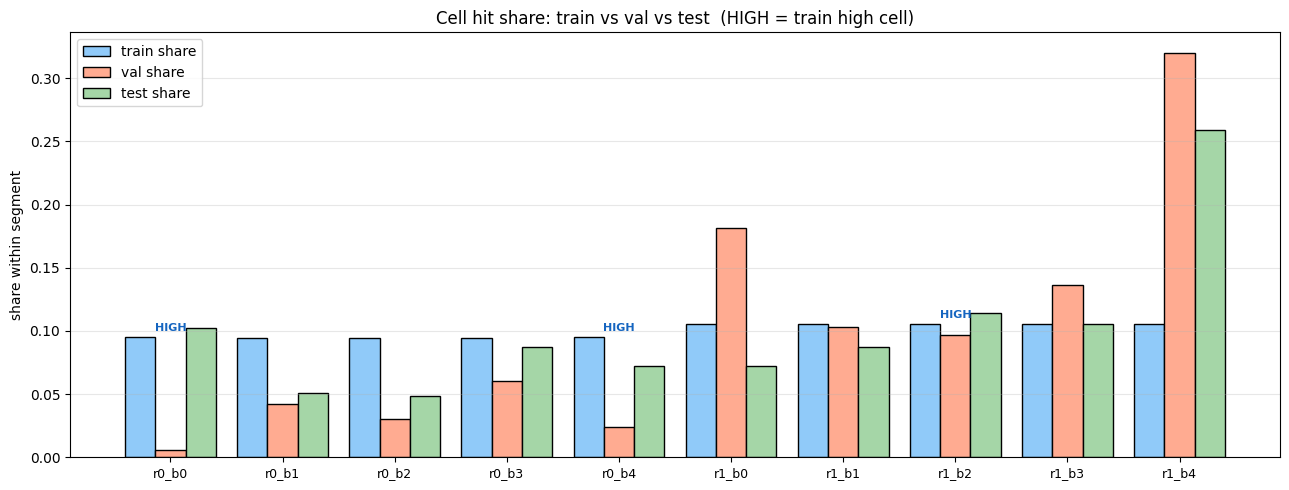

cell_label  n_train  n_val  n_test  mean_ret_train confidence
     r0_b0      148      2      34       -0.004162       high
     r0_b1      147     14      17       -0.000163        low
     r0_b2      147     10      16        0.000111        low
     r0_b3      147     20      29        0.000414        low
     r0_b4      148      8      24        0.005228       high
     r1_b0      165     60      24       -0.000833        low
     r1_b1      164     34      29        0.000437        low
     r1_b2      164     32      38        0.001107       high
     r1_b3      164     45      35        0.000564        low
     r1_b4      165    106      86        0.001115        low


In [189]:
val_hits  = val_backtest.groupby(['regime', 'signal_bin']).size().rename('n_val')
test_hits = test_frame.groupby(['regime', 'signal_bin']).size().rename('n_test')

cell_hits = lk[['regime', 'signal_bin', 'n', 'mean_ret', 'confidence']].rename(
    columns={'n': 'n_train', 'mean_ret': 'mean_ret_train'}
)
cell_hits = cell_hits.merge(val_hits.reset_index(),  on=['regime', 'signal_bin'], how='left')
cell_hits = cell_hits.merge(test_hits.reset_index(), on=['regime', 'signal_bin'], how='left')
cell_hits['n_val']  = cell_hits['n_val'].fillna(0).astype(int)
cell_hits['n_test'] = cell_hits['n_test'].fillna(0).astype(int)
cell_hits['cell_label'] = cell_hits.apply(lambda r: f"r{int(r['regime'])}_b{int(r['signal_bin'])}", axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
xpos = np.arange(len(cell_hits))
bw = 0.27
n_train_share = cell_hits['n_train'] / cell_hits['n_train'].sum()
n_val_share   = cell_hits['n_val']   / max(cell_hits['n_val'].sum(), 1)
n_test_share  = cell_hits['n_test']  / max(cell_hits['n_test'].sum(), 1)

ax.bar(xpos - bw, n_train_share, width=bw, color='#90CAF9', edgecolor='black', label='train share')
ax.bar(xpos,      n_val_share,   width=bw, color='#FFAB91', edgecolor='black', label='val share')
ax.bar(xpos + bw, n_test_share,  width=bw, color='#A5D6A7', edgecolor='black', label='test share')

for i, row in cell_hits.iterrows():
    if row['n_test'] == 0:
        ax.annotate('n_test=0', xy=(xpos[i], 0.005), ha='center', fontsize=8,
                    color='#B71C1C', fontweight='bold', rotation=90, va='bottom')
    if row['confidence'] == 'high':
        ax.annotate('HIGH', xy=(xpos[i], n_train_share.iloc[i] + 0.005),
                    ha='center', fontsize=8, color='#1565C0', fontweight='bold')

ax.set_xticks(xpos)
ax.set_xticklabels(cell_hits['cell_label'], rotation=0, fontsize=9)
ax.set_ylabel('share within segment')
ax.set_title('Cell hit share: train vs val vs test  (HIGH = train high cell)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(cell_hits[['cell_label', 'n_train', 'n_val', 'n_test',
                 'mean_ret_train', 'confidence']].to_string(index=False))

---
## 3  Run final config on test

In [190]:
def daily_position(row, unc_thresh, low_conf_size):
    if pd.isna(row['confidence']):
        return 0.0
    if row['posterior_max'] < unc_thresh:
        return 0.0
    if row['confidence'] == 'no_trade':
        return 0.0
    direction = np.sign(row['mean_ret'])
    if row['confidence'] == 'high':
        return float(direction)
    # low confidence：直接用 low_conf_size 控制仓位
    # low_conf_size=0 等价于原来的 no_trade
    return low_conf_size * float(direction)

def evaluate_combo(frame, unc_thresh, low_conf_size, cost_bp=2.0):
    df = frame.copy()
    df['position'] = df.apply(
        lambda r: daily_position(r, unc_thresh, low_conf_size), axis=1
    )
    df['turnover']  = df['position'].diff().abs().fillna(df['position'].abs())
    df['gross_pnl'] = df['position'] * df['r_next']
    df['cost']      = df['turnover'] * (cost_bp / 1e4)
    df['net_pnl']   = df['gross_pnl'] - df['cost']

    valid   = df.dropna(subset=['r_next'])
    nonzero = valid[valid['position'] != 0]
    if len(nonzero) >= 5:
        ic, _ = spearmanr(nonzero['position'], nonzero['r_next'])
    else:
        ic = np.nan

    n_total      = len(valid)
    n_zero       = (valid['position'] == 0).sum()
    pct_no_trade = n_zero / n_total if n_total > 0 else np.nan

    by_regime = valid.groupby('regime').agg(
        n=('position', 'size'),
        n_traded=('position', lambda s: (s != 0).sum()),
        net_pnl=('net_pnl', 'sum'),
        hit_rate=('gross_pnl', lambda s: (s[s != 0] > 0).mean() if (s != 0).any() else np.nan),
    )

    summary = {
        'unc_thresh':    unc_thresh,
        'low_conf_size': low_conf_size,
        'rank_IC':       ic,
        'net_pnl_total': df['net_pnl'].sum(),
        'pct_no_trade':  pct_no_trade,
        'mean_turnover': df['turnover'].mean(),
        'n_traded':      (valid['position'] != 0).sum(),
    }
    return summary, df, by_regime

test_summary, test_full, test_by_regime = evaluate_combo(
    test_frame,
    final_params['regime_uncertainty_threshold'],
    final_params['low_conf_size'],
    cost_bp=final_params['cost_per_turnover_bp'],
)

print('=== test summary (final params) ===')
for k, v in test_summary.items():
    if isinstance(v, float):
        print(f'  {k:20s}: {v:.6f}')
    else:
        print(f'  {k:20s}: {v}')
print()
print('=== val baseline (for direct comparison) ===')
val_summary_ref = execution_params['final_val_summary']
for k, v in val_summary_ref.items():
    print(f'  {k:25s}: {v}')
print()
print('=== test per-regime breakdown ===')
print(test_by_regime)
print()
print('=== val per-regime (for direct comparison) ===')
print(pd.DataFrame(execution_params['final_per_regime']).T)

=== test summary (final params) ===
  unc_thresh          : 0.600000
  low_conf_size       : 0.500000
  rank_IC             : 0.018855
  net_pnl_total       : 0.171603
  pct_no_trade        : 0.018127
  mean_turnover       : 0.396084
  n_traded            : 325

=== val baseline (for direct comparison) ===
  rank_IC                  : -0.07233484096840426
  net_pnl_total            : 0.020648617782004303
  pct_no_trade             : 0.021148036253776436
  mean_turnover            : 0.324773413897281
  n_traded                 : 324
  n_total_val_days         : 331

=== test per-regime breakdown ===
          n  n_traded   net_pnl  hit_rate
regime                                   
0       120       116  0.201858  0.491379
1       211       209 -0.030255  0.538462

=== val per-regime (for direct comparison) ===
       n  n_traded   net_pnl  hit_rate
0   54.0      53.0  0.054897  0.528302
1  277.0     271.0 -0.034249  0.479705


---
### 3.1 Position sanity viz

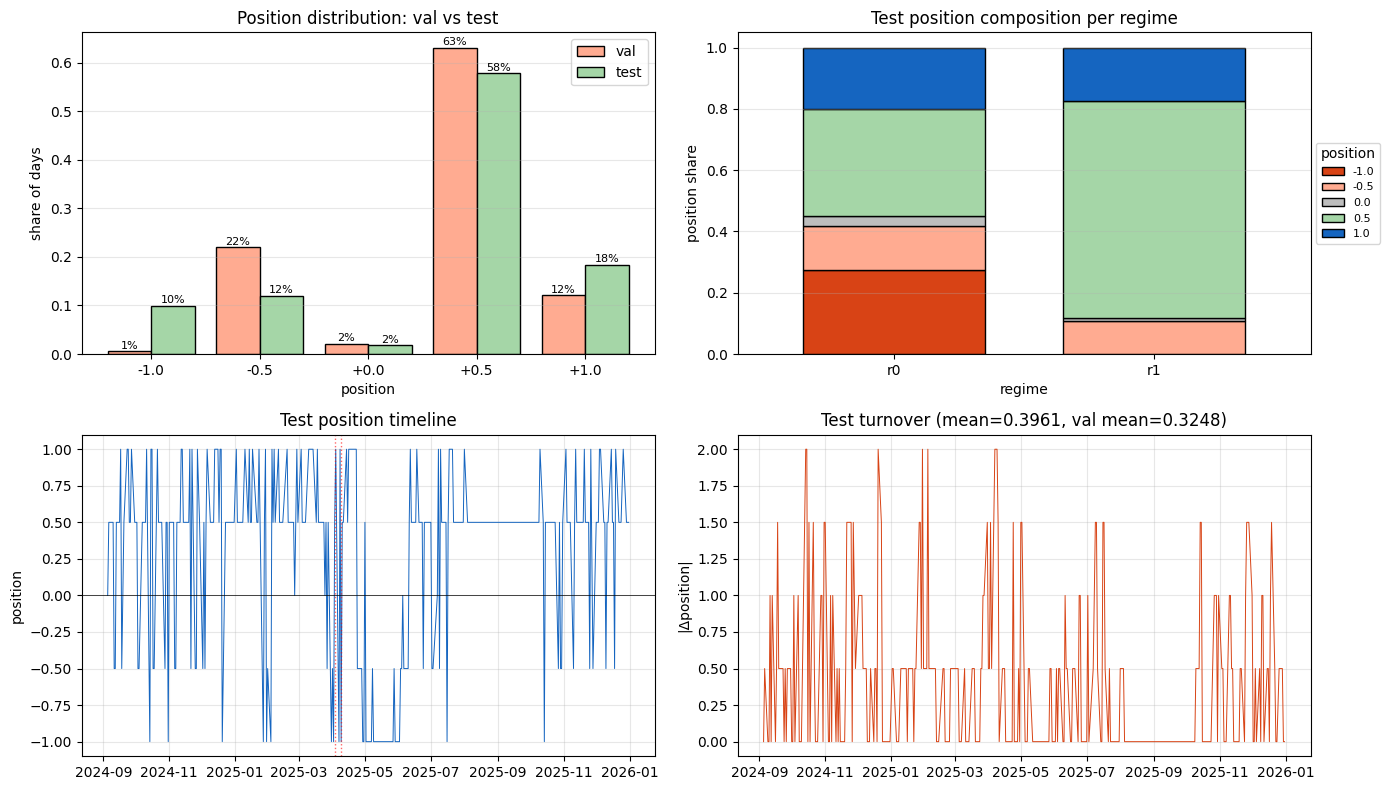

=== position breakdown ===
val total non-zero days  : 324
test total non-zero days : 326
val pct_no_trade         : 0.021148036253776436
test pct_no_trade        : 0.01812688821752266
position
-1.0     33
-0.5     40
 0.0      6
 0.5    192
 1.0     61
Name: count, dtype: int64
low_conf_size used: 0.5
position
-1.0      2
-0.5     73
 0.0      7
 0.5    209
 1.0     40
Name: count, dtype: int64


In [191]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
pos_counts     = test_full['position'].round(4).value_counts().sort_index()
val_pos_counts = val_backtest['position'].round(4).value_counts().sort_index()
all_positions  = sorted(set(pos_counts.index) | set(val_pos_counts.index))
xpos = np.arange(len(all_positions))
bw = 0.4
val_vals  = [val_pos_counts.get(p, 0) / len(val_backtest) for p in all_positions]
test_vals = [pos_counts.get(p, 0)     / len(test_full)    for p in all_positions]
ax.bar(xpos - bw/2, val_vals,  width=bw, color='#FFAB91', edgecolor='black', label='val')
ax.bar(xpos + bw/2, test_vals, width=bw, color='#A5D6A7', edgecolor='black', label='test')
for i, p in enumerate(all_positions):
    ax.text(i - bw/2, val_vals[i]  + 0.005, f'{val_vals[i]:.0%}',  ha='center', fontsize=8)
    ax.text(i + bw/2, test_vals[i] + 0.005, f'{test_vals[i]:.0%}', ha='center', fontsize=8)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{p:+.1f}' for p in all_positions])
ax.set_xlabel('position')
ax.set_ylabel('share of days')
ax.set_title('Position distribution: val vs test')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
reg_pos_share = test_full.groupby(['regime', 'position']).size().unstack(fill_value=0)
reg_pos_share = reg_pos_share.div(reg_pos_share.sum(axis=1), axis=0)
reg_pos_share.plot(kind='bar', stacked=True, ax=ax,
                   color=['#D84315', '#FFAB91', '#BDBDBD', '#A5D6A7', '#1565C0'],
                   edgecolor='black', width=0.7)
ax.set_xlabel('regime')
ax.set_ylabel('position share')
ax.set_title('Test position composition per regime')
ax.set_xticklabels(['r0', 'r1'], rotation=0)
ax.legend(title='position', fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.plot(test_full.index, test_full['position'].values, color='#1565C0', linewidth=0.7)
events = {'2024-08-05': 'Vol', '2025-04-03': 'Tariff', '2025-04-09': 'Pause'}
for d, name in events.items():
    d = pd.Timestamp(d)
    if test_full.index.min() <= d <= test_full.index.max():
        ax.axvline(d, color='red', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('position')
ax.set_title('Test position timeline')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(test_full.index, test_full['turnover'].values, color='#D84315', linewidth=0.7)
ax.set_ylabel('|Δposition|')
ax.set_title(f'Test turnover (mean={test_full["turnover"].mean():.4f}, val mean={val_summary_ref["mean_turnover"]:.4f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== position breakdown ===')
print('val total non-zero days  :', (val_backtest['position'] != 0).sum())
print('test total non-zero days :', (test_full['position'] != 0).sum())
print('val pct_no_trade         :', val_summary_ref['pct_no_trade'])
print('test pct_no_trade        :', test_summary['pct_no_trade'])

print(test_full['position'].value_counts().sort_index())
print("low_conf_size used:", final_params.get('low_conf_size'))

print(val_backtest['position'].value_counts().sort_index())

In [198]:
# ── 多头 / 空头收益分解 ───────────────────────────────────
print('\n=== Long / Short PnL decomposition ===')

for label, df in [('val', val_backtest), ('test', test_full)]:
    long_mask  = df['position'] > 0
    short_mask = df['position'] < 0

    long_gross  = (df.loc[long_mask,  'position'] * df.loc[long_mask,  'r_next']).sum()
    short_gross = (df.loc[short_mask, 'position'] * df.loc[short_mask, 'r_next']).sum()
    long_cost   = df.loc[long_mask,  'cost'].sum()
    short_cost  = df.loc[short_mask, 'cost'].sum()
    long_net    = long_gross  - long_cost
    short_net   = short_gross - short_cost

    long_days  = long_mask.sum()
    short_days = short_mask.sum()
    total_days = len(df)

    long_hit  = (df.loc[long_mask,  'gross_pnl'] > 0).mean() if long_days  > 0 else np.nan
    short_hit = (df.loc[short_mask, 'gross_pnl'] > 0).mean() if short_days > 0 else np.nan

    print(f'\n  [{label}]')
    print(f'  {"":20s} {"Long":>12} {"Short":>12} {"Total":>12}')
    print(f'  {"-"*58}')
    print(f'  {"days":20s} {long_days:>12} {short_days:>12} {total_days:>12}')
    print(f'  {"pct of days":20s} {long_days/total_days:>12.1%} {short_days/total_days:>12.1%} {"":>12}')
    print(f'  {"gross pnl":20s} {long_gross:>12.4f} {short_gross:>12.4f} {long_gross+short_gross:>12.4f}')
    print(f'  {"cost":20s} {long_cost:>12.4f} {short_cost:>12.4f} {long_cost+short_cost:>12.4f}')
    print(f'  {"net pnl":20s} {long_net:>12.4f} {short_net:>12.4f} {long_net+short_net:>12.4f}')
    print(f'  {"hit rate":20s} {long_hit:>12.1%} {short_hit:>12.1%} {"":>12}')

# ── 按 regime × 方向 进一步拆分 ──────────────────────────
print('\n=== Long / Short PnL by regime (test) ===')
rows = []
for r in [0, 1]:
    for direction, mask_fn in [('long', lambda p: p > 0), ('short', lambda p: p < 0)]:
        sub = test_full[(test_full['regime'] == r) & mask_fn(test_full['position'])]
        rows.append({
            'regime':    f'r{r}',
            'direction': direction,
            'days':      len(sub),
            'gross_pnl': (sub['position'] * sub['r_next']).sum(),
            'net_pnl':   sub['net_pnl'].sum(),
            'hit_rate':  (sub['gross_pnl'] > 0).mean() if len(sub) > 0 else np.nan,
        })

breakdown_df = pd.DataFrame(rows)
print(breakdown_df.round(4).to_string(index=False))


=== Long / Short PnL decomposition ===

  [val]
                               Long        Short        Total
  ----------------------------------------------------------
  days                          249           75          331
  pct of days                 75.2%        22.7%             
  gross pnl                  0.1141      -0.0719       0.0421
  cost                       0.0134       0.0073       0.0207
  net pnl                    0.1007      -0.0792       0.0214
  hit rate                    54.6%        29.3%             

  [test]
                               Long        Short        Total
  ----------------------------------------------------------
  days                          253           73          332
  pct of days                 76.2%        22.0%             
  gross pnl                  0.2096      -0.0117       0.1979
  cost                       0.0158       0.0100       0.0258
  net pnl                    0.1938      -0.0217       0.1721
  hit rate   

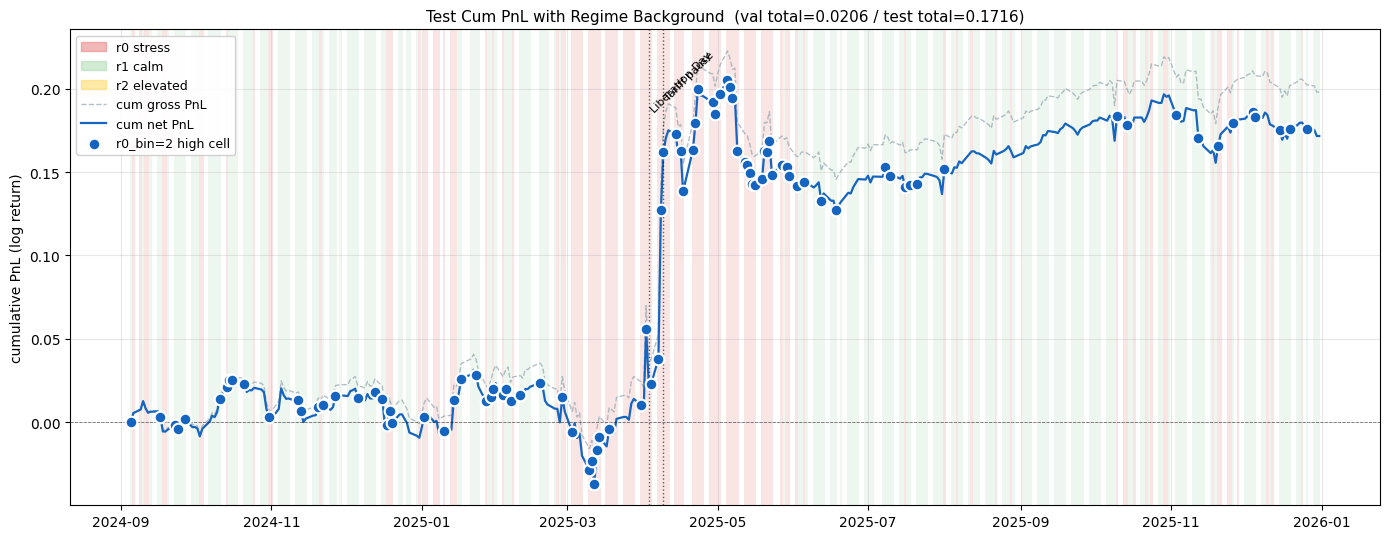


=== test PnL trajectory milestones ===
   25.0% (2025-01-02): cum_net_pnl = 0.0029, cum_gross = 0.0115
   50.0% (2025-05-05): cum_net_pnl = 0.2054, cum_gross = 0.2226
   75.0% (2025-09-03): cum_net_pnl = 0.1656, cum_gross = 0.1867
  100.0% (2025-12-31): cum_net_pnl = 0.1716, cum_gross = 0.1979


In [192]:
test_full['cum_net_pnl']   = test_full['net_pnl'].fillna(0).cumsum()
test_full['cum_gross_pnl'] = test_full['gross_pnl'].fillna(0).cumsum()

fig, ax = plt.subplots(figsize=(14, 5.5))

x = test_full.index
regime_colors = {0: '#E57373', 1: '#A5D6A7', 2: '#FFD54F'}
regime_labels = {0: 'r0 stress', 1: 'r1 calm', 2: 'r2 elevated'}

regimes = test_full['regime'].values
for i in range(len(x)):
    ax.axvspan(x[i] - pd.Timedelta(hours=12),
               x[i] + pd.Timedelta(hours=12),
               alpha=0.18, color=regime_colors[regimes[i]], linewidth=0)

ax.plot(x, test_full['cum_gross_pnl'].values, color='#90A4AE', linewidth=1.0,
        linestyle='--', label='cum gross PnL', alpha=0.7)
ax.plot(x, test_full['cum_net_pnl'].values,   color='#1565C0', linewidth=1.6,
        label='cum net PnL')

high_mask = test_full['confidence'] == 'high'
high_x = x[high_mask]
high_y = test_full.loc[high_mask, 'cum_net_pnl'].values
ax.scatter(high_x, high_y, s=70, color='#1565C0', edgecolor='white',
           linewidth=1.5, zorder=5, label='r0_bin=2 high cell')

events = {
    '2024-08-05': 'Vol spike',
    '2025-04-03': 'Liberation Day',
    '2025-04-09': 'Tariff pause',
}
for d, name in events.items():
    d = pd.Timestamp(d)
    if x.min() <= d <= x.max():
        ax.axvline(d, color='black', linestyle=':', linewidth=1, alpha=0.6)
        ax.text(d, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0,
                name, rotation=45, fontsize=8, ha='left', va='top')

ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_title(f'Test Cum PnL with Regime Background  '
             f'(val total={val_summary_ref["net_pnl_total"]:.4f} / test total={test_summary["net_pnl_total"]:.4f})',
             fontsize=11)
ax.set_ylabel('cumulative PnL (log return)')
ax.grid(True, alpha=0.3)

regime_patches = [mpatches.Patch(color=regime_colors[r], alpha=0.5, label=regime_labels[r]) for r in [0, 1, 2]]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=regime_patches + handles, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print('\n=== test PnL trajectory milestones ===')
n = len(test_full)
for q in [0.25, 0.5, 0.75, 1.0]:
    idx = int(n * q) - 1
    label = test_full.index[idx]
    label_str = str(label.date())
    print(f'  {q*100:>5.1f}% ({label_str}): cum_net_pnl = {test_full.iloc[idx]["cum_net_pnl"]:.4f}, '
          f'cum_gross = {test_full.iloc[idx]["cum_gross_pnl"]:.4f}')


=== test segment: strategy vs buy-and-hold ===
           strategy  net_pnl_total  ann_ret  ann_vol  sharpe   max_dd  rank_IC
   SPY buy-and-hold        0.21571  0.16373  0.17175 0.95333 -0.21014      NaN
Step 8 final (test)        0.17160  0.13025  0.13619 0.95640 -0.07814  0.01855


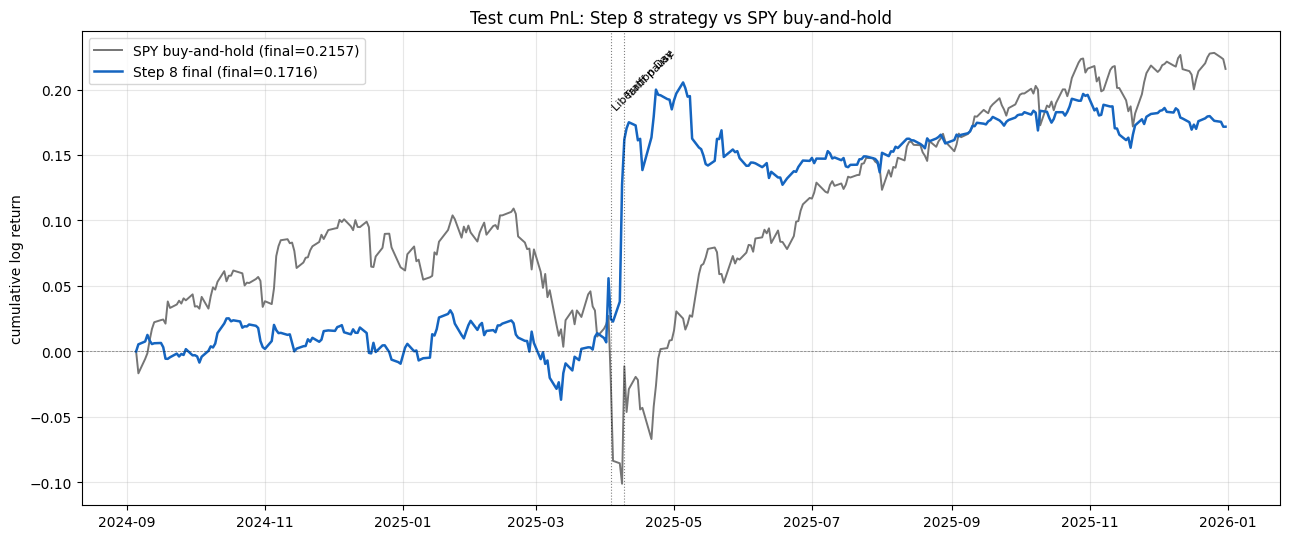

In [193]:
# ── Buy & Hold 基准 ───────────────────────────────────────
test_dates_for_baseline = test_full.index
spy_close    = daily_close.reindex(test_dates_for_baseline).dropna()
buy_hold_ret = np.log(spy_close / spy_close.shift(1)).reindex(test_dates_for_baseline).fillna(0)
buy_hold_cum = buy_hold_ret.cumsum()

# ── 对比表 ────────────────────────────────────────────────
def strategy_stats(label, ret_series, position_series=None):
    ret    = ret_series.dropna()
    sharpe = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else np.nan
    cum    = ret.cumsum()
    peak   = np.maximum.accumulate(cum)
    dd     = (cum - peak).min()
    if position_series is not None:
        nz = position_series[position_series != 0]
        if len(nz) >= 5:
            ic, _ = spearmanr(nz, test_full['r_next'].reindex(nz.index).fillna(0))
        else:
            ic = np.nan
    else:
        ic = np.nan
    return {
        'strategy':      label,
        'net_pnl_total': ret.sum(),
        'ann_ret':       ret.mean() * 252,
        'ann_vol':       ret.std() * np.sqrt(252),
        'sharpe':        sharpe,
        'max_dd':        dd,
        'rank_IC':       ic,
    }

baseline_df = pd.DataFrame([
    strategy_stats('SPY buy-and-hold',      buy_hold_ret),
    strategy_stats('Step 8 final (test)',   test_full['net_pnl'].fillna(0),
                                            test_full['position']),
])

print('\n=== test segment: strategy vs buy-and-hold ===')
print(baseline_df.round(5).to_string(index=False))

# ── 累计 PnL 对比图 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(test_full.index, buy_hold_cum.values,
        color='#757575', linewidth=1.4,
        label=f'SPY buy-and-hold (final={buy_hold_cum.iloc[-1]:.4f})')
ax.plot(test_full.index, test_full['cum_net_pnl'].values,
        color='#1565C0', linewidth=1.8,
        label=f'Step 8 final (final={test_full["cum_net_pnl"].iloc[-1]:.4f})')

for d, name in events.items():
    d = pd.Timestamp(d)
    if test_full.index.min() <= d <= test_full.index.max():
        ax.axvline(d, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.text(d, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0,
                name, rotation=45, fontsize=8, ha='left', va='top')

ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_ylabel('cumulative log return')
ax.set_title('Test cum PnL: Step 8 strategy vs SPY buy-and-hold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
#几个策略对比

1.无regime conditioning

In [194]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr

[Ablation 1] Pooled Ridge  best_alpha=2.0691  CV_IC=0.1184

=== Ablation 1 — Pooled vs Regime-Conditional Ridge (Test Segment) ===
                          Model  AnnRet  AnnVol  Sharpe   MaxDD  Coverage  RankIC
Full model (regime-conditional)  0.1303  0.1362   0.956 -0.0781     0.982  0.0189
       Ablation 1: Pooled Ridge  0.0235  0.1723   0.137 -0.1779     1.000 -0.0291


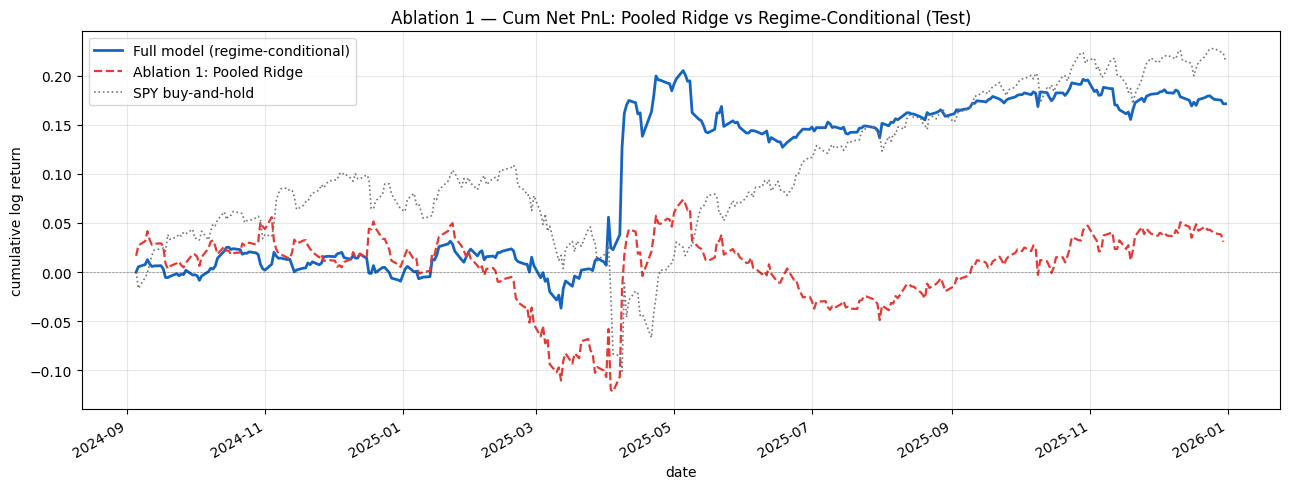

In [195]:

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# ── 1. 重建 train 特征矩阵 ────────────────────────────────────
# feature_names / X_P_residual / regime_forward / regime_post /
# r_next / train_start / train_end 均来自 Step 9 已有变量

train_start = pd.Timestamp(splits['train']['start'])
train_end   = pd.Timestamp(splits['train']['end'])

# 列名映射（与 Step 9 Cell 3 保持一致）
base_cols = [fn.replace('_resid', '') if fn.replace('_resid', '') in X_P_residual.columns
             else fn
             for fn in feature_names]

def _build_frame(start, end, boundary_drop=5):
    """切出指定段的特征 + regime + posterior_max + r_next，对齐后删边界。"""
    xp = X_P_residual.loc[start:end, base_cols].copy()
    xp.columns = feature_names                          # 统一列名

    regime_col = regime_forward.columns[0]
    reg = regime_forward[regime_col].reindex(xp.index)

    post_vals = regime_post.reindex(xp.index).values
    post_max  = pd.Series(post_vals.max(axis=1), index=xp.index, name='posterior_max')

    r = r_next.reindex(xp.index)

    df = pd.concat([xp, reg.rename('regime'), post_max, r], axis=1).dropna()
    return df.iloc[boundary_drop:]

train_df_abl = _build_frame(train_start, train_end)
# test_frame 已在 Step 9 构建好，直接复用其特征列
# 但需要原始（未 merge lookup 前）的 signal 列，所以重新对齐特征
test_xp = X_P_residual.loc[resid_test_trimmed.index, base_cols].copy()
test_xp.columns = feature_names

X_train_pool = train_df_abl[feature_names].values
y_train_pool = train_df_abl['r_next'].values

# ── 2. CV 选 alpha（pooled，不分 regime）────────────────────
tscv_abl    = TimeSeriesSplit(n_splits=5)
alpha_grid  = np.logspace(-2, 2, 20)
scaler_pool = StandardScaler().fit(X_train_pool)
Xs_pool     = scaler_pool.transform(X_train_pool)

best_alpha_pool, best_ic_pool = None, -np.inf
for a in alpha_grid:
    ic_folds = []
    for tr, te in tscv_abl.split(Xs_pool):
        m  = Ridge(alpha=a).fit(Xs_pool[tr], y_train_pool[tr])
        yp = m.predict(Xs_pool[te])
        ic_folds.append(spearmanr(y_train_pool[te], yp).correlation)
    mean_ic = np.nanmean(ic_folds)
    if mean_ic > best_ic_pool:
        best_ic_pool   = mean_ic
        best_alpha_pool = a

print(f"[Ablation 1] Pooled Ridge  best_alpha={best_alpha_pool:.4f}  CV_IC={best_ic_pool:.4f}")

# ── 3. 在全 train 上 refit ───────────────────────────────────
pooled_model = Ridge(alpha=best_alpha_pool).fit(Xs_pool, y_train_pool)

# ── 4. 在 test 上生成 signal ─────────────────────────────────
X_test_pool    = scaler_pool.transform(test_xp.values)
signal_pooled  = pd.Series(
    pooled_model.predict(X_test_pool),
    index=resid_test_trimmed.index,
    name='signal_pooled'
)

# ── 5. 执行层：signal 符号直接作为仓位 ──────────────────────
# 说明：lookup table 本身是 regime-conditional 构造的，
# 用 pooled signal 查 regime-conditional lookup 会混淆实验。
# 这里用 sign(signal) ± 1 作为仓位，隔离 regime conditioning 的贡献。
pos_pooled = np.sign(signal_pooled)

# 对齐 r_next（与 test_full 使用同一来源）
r_next_test    = r_next.reindex(resid_test_trimmed.index)
ret_pooled_gross = (pos_pooled * r_next_test).dropna()

# 计算 turnover 和 net pnl（与 evaluate_combo 逻辑一致）
turnover_pooled  = pos_pooled.diff().abs().fillna(pos_pooled.abs())
cost_pooled      = turnover_pooled * (final_params['cost_per_turnover_bp'] / 1e4)
ret_pooled_net   = (pos_pooled * r_next_test - cost_pooled).dropna()

# ── 6. 统计对比 ──────────────────────────────────────────────
def ablation_stats(label, net_ret, pos_series=None, sig_series=None):
    r   = net_ret.dropna()
    ann = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    sr  = ann / vol if vol > 0 else np.nan
    cum = r.cumsum()
    dd  = (cum - np.maximum.accumulate(cum)).min()
    cov = (pos_series != 0).mean() if pos_series is not None else np.nan
    
    if pos_series is not None:
        nz_idx     = pos_series[pos_series != 0].index
        pos_nz     = pos_series.reindex(nz_idx)
        ret_nz     = r_next_test.reindex(nz_idx)
        valid_mask = pos_nz.notna() & ret_nz.notna()
        if valid_mask.sum() >= 5:
            ic, _ = spearmanr(pos_nz[valid_mask], ret_nz[valid_mask])
        else:
            ic = np.nan
    else:
        ic = np.nan
        
    return {'Model': label, 'AnnRet': round(ann,4), 'AnnVol': round(vol,4),
            'Sharpe': round(sr,3), 'MaxDD': round(dd,4),
            'Coverage': round(cov,3), 'RankIC': round(ic,4)}

rows_abl = [
    # Full model：从 test_full 取 net_pnl（已含 cost），position 来自 test_full
    ablation_stats(
        'Full model (regime-conditional)',
        test_full['net_pnl'].fillna(0),
        pos_series=test_full['position'],
        sig_series=test_full['signal']          # test_frame 里已有 signal 列
    ),
    ablation_stats(
        'Ablation 1: Pooled Ridge',
        ret_pooled_net,
        pos_series=pos_pooled,
        sig_series=signal_pooled
    ),
]

abl_df = pd.DataFrame(rows_abl)
print('\n=== Ablation 1 — Pooled vs Regime-Conditional Ridge (Test Segment) ===')
print(abl_df.to_string(index=False))

# ── 7. 累计 PnL 对比图 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
test_full['net_pnl'].fillna(0).cumsum().plot(
    ax=ax, color='#1565C0', lw=2, label='Full model (regime-conditional)')
ret_pooled_net.fillna(0).cumsum().plot(
    ax=ax, color='#E53935', lw=1.6, ls='--', label='Ablation 1: Pooled Ridge')
buy_hold_cum.plot(
    ax=ax, color='#757575', lw=1.2, ls=':', label='SPY buy-and-hold')
ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.set_title('Ablation 1 — Cum Net PnL: Pooled Ridge vs Regime-Conditional (Test)')
ax.set_ylabel('cumulative log return')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[Ablation 2] X_P_raw shape: (2745, 6)
[Ablation 2] NaN per column:
 CloseLoc               0
SignedVolume_z252    503
PriceVolCorr_z252    503
Overnight              1
Mom_60d               60
Mom_20d               20
dtype: int64
[Ablation 2] train samples after NaN drop: 1564
[Ablation 2] Regime 0: alpha=100.0000  CV_IC=0.0508
[Ablation 2] Regime 1: alpha=3.3598  CV_IC=0.0273
[Ablation 2] signal_raw non-NaN: 332 / 332

=== Ablation 1 & 2 — Summary Table (Test Segment) ===
                           Model  AnnRet  AnnVol  Sharpe   MaxDD  Coverage  RankIC
 Full model (regime-conditional)  0.1303  0.1362   0.956 -0.0781     0.982  0.0189
        Ablation 1: Pooled Ridge  0.0235  0.1723   0.137 -0.1779     1.000 -0.0291
Ablation 2: Raw features (no L1)  0.1103  0.1210   0.912 -0.0566     0.982 -0.0242


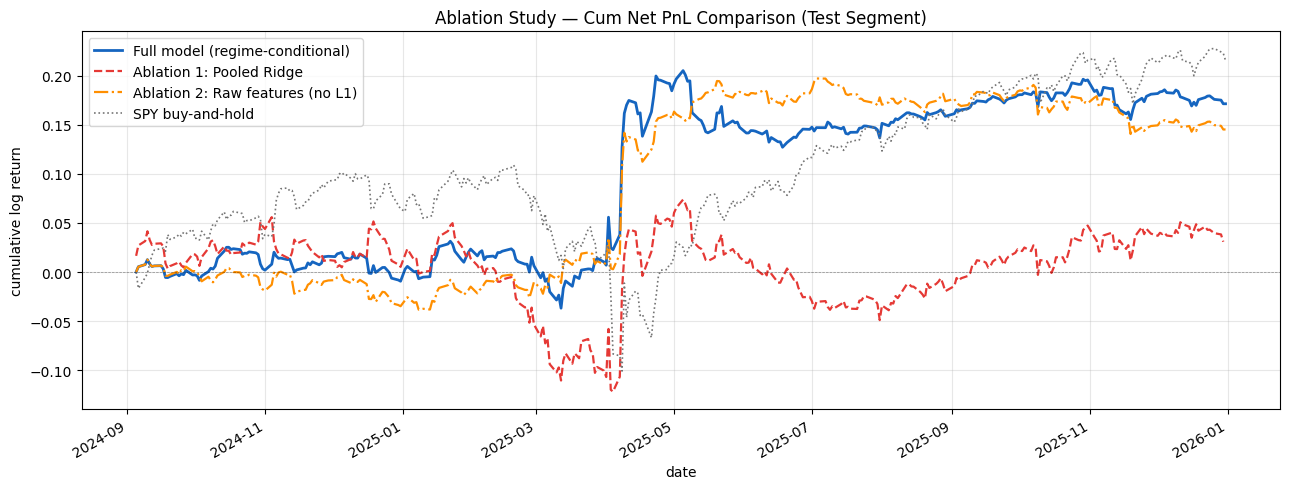

In [196]:
# ══════════════════════════════════════════════════════════════
# Ablation 2: Raw X_P features（无 L1 Decomposition）
# 前提：Ablation 1 已运行（依赖 train_df_abl / train_start / train_end）
# ══════════════════════════════════════════════════════════════

# ── 1. 加载原始因子矩阵，应用 Step 4 锁定的变换 ──────────────
factors_full = pd.read_parquet(DATA / 'spy_factors_step2.parquet')

# feature_names 形如 ['SignedVolume_z252_resid', ...]
# 去掉 _resid 后缀得到原始列名
X_P_factors = [fn.replace('_resid', '') if fn.replace('_resid', '') in factors_full.columns
               else fn
               for fn in feature_names]

def _signed_log_scaled(x, scale):
    return np.sign(x) * np.log1p(np.abs(x) * scale)

X_P_raw = factors_full[X_P_factors].copy()

# 仅对 Overnight 做 signed_log_scaled，其他因子 identity（与 Step 6 Section 2 一致）
if 'Overnight' in X_P_raw.columns:
    X_P_raw['Overnight'] = _signed_log_scaled(X_P_raw['Overnight'], 1e2)

print('[Ablation 2] X_P_raw shape:', X_P_raw.shape)
print('[Ablation 2] NaN per column:\n', X_P_raw.isna().sum())

# ── 2. 构建 train 特征矩阵（复用 Ablation 1 的 train_df_abl）────
# train_df_abl 已有 regime 列，直接用
# 用 raw features 替换 residual features

X_raw_train = X_P_raw.reindex(train_df_abl.index)[X_P_factors].values
y_raw_train  = train_df_abl['r_next'].values

# 检查是否有 NaN（raw factors 在 train 段可能有 burn-in NaN）
valid_mask_train = ~np.isnan(X_raw_train).any(axis=1) & ~np.isnan(y_raw_train)
X_raw_train = X_raw_train[valid_mask_train]
y_raw_train  = y_raw_train[valid_mask_train]
regimes_train = train_df_abl['regime'].values[valid_mask_train]

print(f'[Ablation 2] train samples after NaN drop: {len(X_raw_train)}')

# ── 3. 按 regime 分别 CV + fit（regime-conditional，只换 features）
regime_models_raw = {}
scalers_raw       = {}
alpha_locked_raw  = {}

for reg_id in sorted(train_df_abl['regime'].unique()):
    reg_id = int(reg_id)
    mask_r = regimes_train == reg_id
    Xr = X_raw_train[mask_r]
    yr = y_raw_train[mask_r]

    if len(Xr) < 30:
        print(f'[Ablation 2] Regime {reg_id}: too few samples ({len(Xr)}), skip')
        continue

    scaler_r = StandardScaler().fit(Xr)
    Xrs      = scaler_r.transform(Xr)

    best_a_r, best_ic_r = None, -np.inf
    for a in alpha_grid:          # alpha_grid 来自 Ablation 1
        ic_folds = []
        for tr, te in TimeSeriesSplit(n_splits=5).split(Xrs):
            m  = Ridge(alpha=a).fit(Xrs[tr], yr[tr])
            yp = m.predict(Xrs[te])
            ic_folds.append(spearmanr(yr[te], yp).correlation)
        mean_ic = np.nanmean(ic_folds)
        if mean_ic > best_ic_r:
            best_ic_r = mean_ic
            best_a_r  = a

    regime_models_raw[reg_id] = Ridge(alpha=best_a_r).fit(Xrs, yr)
    scalers_raw[reg_id]       = scaler_r
    alpha_locked_raw[reg_id]  = best_a_r
    print(f'[Ablation 2] Regime {reg_id}: alpha={best_a_r:.4f}  CV_IC={best_ic_r:.4f}')

# ── 4. 在 test 段逐行生成 signal ─────────────────────────────
# 用 resid_test_trimmed.index（与 Step 9 test_frame 完全对齐）
test_index = resid_test_trimmed.index
seg_regime_test = regime_all.reindex(test_index)

signals_raw = np.full(len(test_index), np.nan)
for i, (idx, row_regime) in enumerate(seg_regime_test.items()):
    reg_id = int(row_regime)
    if reg_id not in regime_models_raw:
        continue
    xraw = X_P_raw.reindex([idx])[X_P_factors].values   # shape (1, n_features)
    if np.isnan(xraw).any():
        continue
    xs  = scalers_raw[reg_id].transform(xraw)
    signals_raw[i] = regime_models_raw[reg_id].predict(xs)[0]

signal_raw = pd.Series(signals_raw, index=test_index, name='signal_raw')
print(f'[Ablation 2] signal_raw non-NaN: {signal_raw.notna().sum()} / {len(signal_raw)}')

# ── 5. 执行层：复用 lookup table + daily_position ────────────
# 构造与 test_frame 结构一致的 frame（只替换 signal 列）
frame_raw = pd.DataFrame({
    'regime':        regime_all.reindex(test_index),
    'posterior_max': pd.Series(
                         regime_post.reindex(test_index).values.max(axis=1),
                         index=test_index),
    'signal':        signal_raw,
    'r_next':        r_next.reindex(test_index),
}).dropna(subset=['regime', 'signal'])

# assign bin
frame_raw['signal_bin'] = frame_raw.apply(
    lambda row: assign_bin(row['signal'], row['regime'], edges_by_regime), axis=1
)

# merge lookup table（mean_ret + confidence）
lk_abl = (lookup_table.reset_index()
           if lookup_table.index.name is not None
           else lookup_table.copy())

frame_raw = frame_raw.merge(
    lk_abl[['regime', 'signal_bin', 'mean_ret', 'confidence']],
    on=['regime', 'signal_bin'],
    how='left',
)
frame_raw.index = test_index[:len(frame_raw)]   # 保持 DatetimeIndex

# 生成仓位
frame_raw['position'] = frame_raw.apply(
    lambda row: daily_position(
        row,
        final_params['regime_uncertainty_threshold'],
        final_params['low_conf_size']
    ), axis=1
)

# 计算 PnL
frame_raw['gross_pnl'] = frame_raw['position'] * frame_raw['r_next']
frame_raw['turnover']  = frame_raw['position'].diff().abs().fillna(
                             frame_raw['position'].abs())
frame_raw['cost']      = frame_raw['turnover'] * (final_params['cost_per_turnover_bp'] / 1e4)
frame_raw['net_pnl']   = frame_raw['gross_pnl'] - frame_raw['cost']

# ── 6. 统计对比（复用 Ablation 1 的 ablation_stats 函数）──────
r_next_test = r_next.reindex(test_index)   # 统一 reference

rows_abl2 = [
    ablation_stats(                         # ablation_stats 来自 Ablation 1
        'Full model (regime-conditional)',
        test_full['net_pnl'].fillna(0),
        pos_series=test_full['position'],
        sig_series=test_full['signal']
    ),
    ablation_stats(
        'Ablation 1: Pooled Ridge',
        ret_pooled_net,                     # 来自 Ablation 1
        pos_series=pos_pooled,
        sig_series=signal_pooled
    ),
    ablation_stats(
        'Ablation 2: Raw features (no L1)',
        frame_raw['net_pnl'].fillna(0),
        pos_series=frame_raw['position'],
        sig_series=signal_raw
    ),
]

abl2_df = pd.DataFrame(rows_abl2)
print('\n=== Ablation 1 & 2 — Summary Table (Test Segment) ===')
print(abl2_df.to_string(index=False))

# ── 7. 三条曲线对比图 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

test_full['net_pnl'].fillna(0).cumsum().plot(
    ax=ax, color='#1565C0', lw=2,   label='Full model (regime-conditional)')
ret_pooled_net.fillna(0).cumsum().plot(
    ax=ax, color='#E53935', lw=1.6, ls='--', label='Ablation 1: Pooled Ridge')
frame_raw['net_pnl'].fillna(0).cumsum().plot(
    ax=ax, color='#FF8F00', lw=1.6, ls='-.', label='Ablation 2: Raw features (no L1)')
buy_hold_cum.plot(
    ax=ax, color='#757575', lw=1.2, ls=':',  label='SPY buy-and-hold')

ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.set_title('Ablation Study — Cum Net PnL Comparison (Test Segment)')
ax.set_ylabel('cumulative log return')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()